# Image Processing using Python

#### Ulf D. Schiller <uschill@udel.edu>, University Delaware

These are the notes for the [Image Processing using Python](https://events.hifis.net/event/3395/) course I taught at [Forschungszentrum J&uuml;lich](https://www.fz-juelich.de) for the [International Helmholtz Research School BioSoft](http://www.ihrs-biosoft.de/). The course is closely based on the [Data Carpentry Lesson Program on Image Processing with Python](https://datacarpentry.github.io/image-processing) that I co-maintain for [The Carpentries](). The materials are licensed under [CC-BY 4.0](https://creativecommons.org/licenses/by-sa/4.0/). Please include [appropriate credit](https://creativecommons.org/licenses/by-sa/4.0/#ref-appropriate-credit) when you share or adapt the material.

## About the course

The course introduces fundamental concepts in image handling and processing. Learners will learn to load images into Python, select, summarise, and modify specific image regions, and identify and extract objects within an image for further analysis.

### Prerequiste

I assume that course participants have basic programming skills and are familiar with Python. By _basic_ I mean the skills that are, for example, taught during the course [Python from Zero to Data Science](https://events.hifis.net/event/2386/). You can find a more detailed list of prerequistes [here](https://datacarpentry.github.io/image-processing/prereqs.html).

### Course content

* What scientific questions can we answer with image processing/computer vision?
* What are morphometric problems?
* How are images represented in digital format?
* How can the scikit-image Python computer vision library be used to work with images?
* How can we draw on scikit-image images and use bitwise operations and masks to select certain parts of an image?
* How can we apply a low-pass blurring filter to an image?
* How can we create grayscale and colour histograms to understand an image's distribution of colour values?
* How can we use thresholding to produce a binary image?
* How to extract separate objects from an image and describe these objects quantitatively.
* How can we automatically count bacterial colonies with image analysis?

### Acknowledgments

I thank Thorsten Auth, the Institute for Advanced Simulation (IAS), and the [Theoretical Physics of Living Matter Group](https://www.fz-juelich.de/en/ias/ias-2) for their hospitality and support.

This work was partially supported by the National Science Foundation under NSF Awards [DMR-2414458](https://www.nsf.gov/awardsearch/show-award/?AWD_ID=2414458) and [DMR-2119833](https://www.nsf.gov/awardsearch/show-award/?AWD_ID=2119833). Any opinions, findings and conclusions or recommendations expressed in this material are those of the authors and do not necessarily reflect those of the National Science Foundation.

## Getting started

### Downloading the example data

The example images and a description of the Python environment used in this lesson are available on FigShare. To download the data, please visit [the dataset page for this workshop](https://figshare.com/articles/dataset/Data_Carpentry_Image_Processing_Data_beta_/19260677) and click the “Download all” button. Unzip the downloaded file, and save the contents as a folder called `data`. (The name `data` is optional but recommended, as this is the name we will use to refer to the folder throughout the lesson.)

### Testing your Python environment

To test your environment, run the following cell:

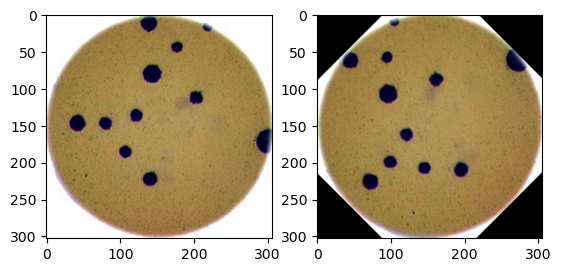

In [1]:
import imageio.v3 as iio
import matplotlib.pyplot as plt
import skimage as ski

# load an image
image = iio.imread(uri='data/colonies-01.tif')

# rotate it by 45 degrees
rotated = ski.transform.rotate(image=image, angle=45)

# display the original image and its rotated version side by side
fig, ax = plt.subplots(1, 2)
ax[0].imshow(image)
ax[1].imshow(rotated)

## Introduction

You may review the full episode [Introduction](https://datacarpentry.github.io/image-processing/01-introduction.html) online.

## Image Basics

You may review the full episode [Image Basics](https://datacarpentry.github.io/image-processing/02-image-basics.html) online.

### Loading Images

If you have copied the image data to the recommended folder `data` in your working directory, you can list the contents by running the following cell:

In [2]:
!ls data/

beads.jpg	       letterA.tif		  sudoku.png
board.jpg	       maize-root-cluster.jpg	  tree.jpg
centers.txt	       maize-roots-grayscale.jpg  trial-016.jpg
chair.jpg	       maize-seedlings.jpg	  trial-020.jpg
clipped_board.tif      maize-seedlings.tif	  trial-216.jpg
colonies-01.tif        plant-seedling.jpg	  trial-293.jpg
colonies-02.tif        remote-control.jpg	  wellplate-01.jpg
colonies-03.tif        resized.jpg		  wellplate-02.tif
eight.tif	       shapes-01.jpg		  ws.bmp
gaussian-original.png  shapes-02.jpg		  ws.jpg


#### Now you:

1. Use a function from the `imageio` library to load the image `data/eight.tif` and store in a Python variable.
2. Create a `matplotlib` figure and display the image. Take a moment to understand how the numbering of the axes translates to "coordinates" of pixels.
3. Modify the `matplotlib` function call such that the image is displayed in grayscale (in this particular case, the pixels will be black or white).
4. Print the data type of the variables that holds the image.
5. Print the shape of the variable that holds the image. What does the output tell us?
6. Print out the variable that holds the image. Can you make sense of the output?

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import imageio.v3 as iio
import matplotlib.pyplot as plt

### TODO ###

### Working with Pixels

An image is commonly stored in a 2D array, in our case a `numpy.ndarray`. The array is organized by rows and columns, and each entry represents a pixel. The value(s) of each pixel determine its color. For a grasyscale image, the value range from 0 to 255 or from 0 to 1, depending on the dtype (integer or float). The value 0 typically translates to the color black. A color image typically uses multiple values to encode the colors. For example, an RGB image uses three "channels" to represent the intensity of red, green, and blue of the pixel. When the pixel is dipslayed with `imshow`, the three values are combined to the corresponding color. For example, the image of the figure eight is stored in an array as follows.

In [4]:
eight = iio.imread("data/eight.tif")
print(eight)

[[0. 0. 0.]
 [0. 1. 0.]
 [0. 0. 0.]
 [0. 1. 0.]
 [0. 0. 0.]]


Since the iamge is stored in a Numpy array, we can directly access and modify each pixel. For example, we can look at the pixel in the top right corner (row 0, colum 0), or the center (row 2, column 1), or the middle of the right edge (row 2, column 2).

In [5]:
print("Top left corner:", eight[0, 0])
print("Center:", eight[2, 1])
print("Middle right edge:", eight[2, 2])

Top left corner: 0.0
Center: 0.0
Middle right edge: 0.0


We can also modify the image. For example, to make the image look like a figure zero, we can change the value of the centremost pixel to 1.

[[0. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 0.]]


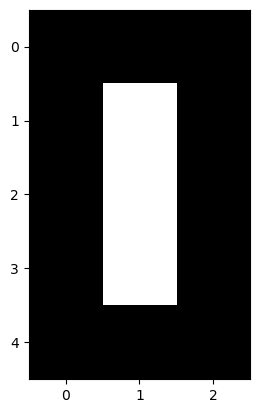

In [6]:
zero = eight.copy()
zero[2, 1] = 1.
print(zero)
plt.imshow(zero, cmap='gray')
plt.show()

#### Now you

1. Create another copy of the figure eight image, and then change the value of pixels such that it looks like a figure five. Display the image and print out the array as well.

In [7]:
### TODO ###

### More colors

So far, we saw only black and white pixels, because the values were either 0 or 1. A common way to represent more colors is to use values between 0 and 255 (8 bit integer) to allow for 256 different gray tones. Let's try it out:

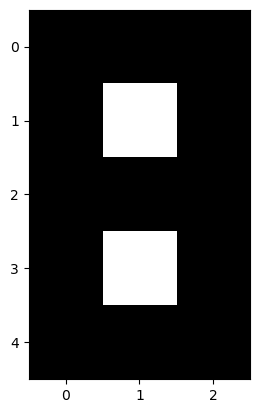

[[  0.   0.   0.]
 [  0. 128.   0.]
 [  0.   0.   0.]
 [  0. 128.   0.]
 [  0.   0.   0.]]


In [8]:
three_colors = eight.copy()

three_colors *= 128

fig, ax = plt.subplots()
ax.imshow(three_colors, cmap='gray')
plt.show()
print(three_colors)

Hmm...? Although the values in the array have changed, the image still appears the same. This is because matplotlib automatically scales the values, i.e., the lowest value corresponds to black and the largest value corresponds to white. But we can add a third gray tone by changing, e.g., the central row:

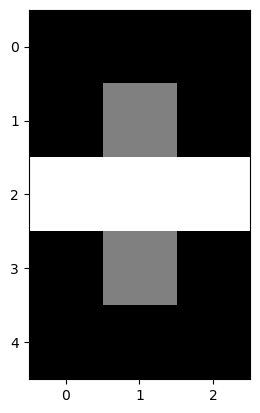

In [9]:
three_colors[2, :] = 255

fig, ax = plt.subplots()
ax.imshow(three_colors, cmap='gray')
plt.show()

### Even more colors

To go beyond grayscale images, we need to use color channels. As mentioned above, a color image is typically encoded using three channels for the colors red, green, and blue. Such images are referred to as RGB images. The color channels are stored in the last dimension of the array. To illustrate this, we create a 4 by 4 random image with random colors:

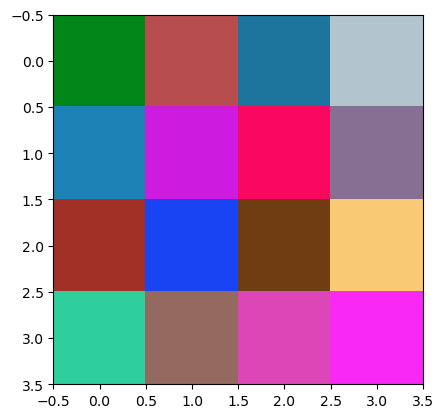

[[[  1 134  26]
  [184  77  77]
  [ 29 116 156]
  [179 197 204]]

 [[ 28 130 182]
  [205  27 224]
  [249   7  96]
  [135 111 148]]

 [[161  48  38]
  [ 25  68 243]
  [112  60  17]
  [250 201 116]]

 [[ 47 207 157]
  [148 105  95]
  [221  70 182]
  [249  40 245]]]


In [10]:
np.random.seed(2026)
canvas = np.random.randint(0, 255, size=(4, 4, 3))

fix, ax = plt.subplots()
ax.imshow(canvas)
plt.show()
print(canvas)

#### Now you

1. Suppose that we represent colours as triples (r, g, b), where each of r, g, and b is an integer in [0, 255]. What colours are represented by each of these triples?
2. There are three colors channels, and each channel uses 8 bits, hence 24 bits are used to encode the color of a pixel. This is called the 24-bit RGB model. How many possible colours can be represented with the 24-bit RGB model?
3. How many bytes are needed to store an 5000 by 5000 image in the 24-bit RGB model?

#### Challenge: Image file sizes

The following code creates a square white image of 5000 x 5000 pixels, and then saves it as a BMP and as a JPEG image.

In [11]:
dim = 5000

img = np.zeros((dim, dim, 3), dtype="uint8")
img.fill(255)

iio.imwrite(uri="data/ws.bmp", image=img)
iio.imwrite(uri="data/ws.jpg", image=img)

1. Examine the file sizes of the two output files, ws.bmp and ws.jpg.
2. Does the BMP image size match our previous prediction?
3. How about the JPEG?

#### Challenge: Lossless vs. lossy compression

Open a terminal (or Windows PowerShell) and navigate to the data/ directory. The two output images, `ws.bmp` and `ws.jpg`, should still be in the directory, along with another image, `tree.jpg`.

We can apply lossless compression to any file by using the `zip` command. Recall that the ws.bmp file contains 75,000,054 bytes. Apply lossless compression to this image by executing the following command: (Compress-Archive ws.bmp ws.zip with PowerShell)
```
zip ws.zip ws.bmp 
```
This command tells the computer to create a new compressed file, ws.zip, from the original bitmap image. Execute a similar command on the `tree.jpg` file: (Compress-Archive tree.jpg tree.zip with PowerShell).
```
zip tree.zip tree.jpg 
```
Having created the compressed file, use the `ls -l` command (dir with PowerShell) to display the contents of the directory. 

1. How big are the compressed files?
2. How do those compare to the size of ws.bmp and tree.jpg?
3. What can you conclude from the relative sizes?

The following example illustrates the effect of lossy compression.

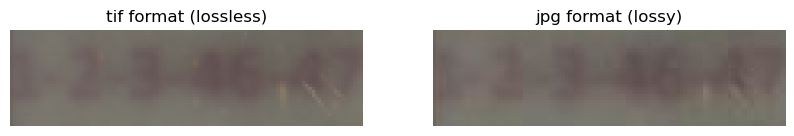

In [12]:
maize_tif = iio.imread("data/maize-seedlings.tif")
iio.imwrite("data/maize-seedlings.jpg", maize_tif)
maize_jpg = iio.imread("data/maize-seedlings.jpg")

fig, ax = plt.subplots(1, 2, figsize=(10, 10))
region = np.s_[60:90, 260:370]
ax[0].imshow(maize_tif[region])
ax[1].imshow(maize_jpg[region])
ax[0].set_title("tif format (lossless)")
ax[1].set_title("jpg format (lossy)")
for a in ax: a.set_axis_off()
plt.show()

## Working with scikit-image

You may review the full episode [Working with scikit-image](https://datacarpentry.github.io/image-processing/03-skimage-images.html) online.

### Reading, displaying, and saving images

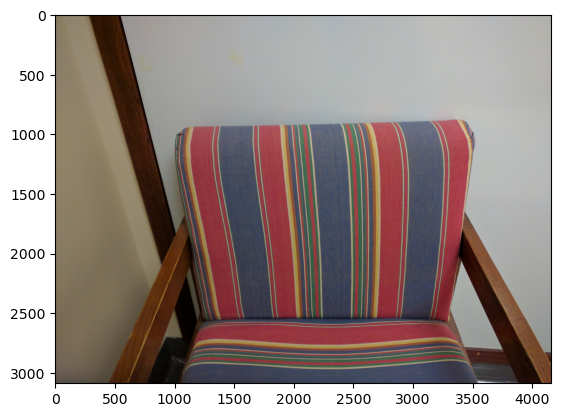

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import imageio.v3 as iio
import skimage as ski

chair = iio.imread(uri="data/chair.jpg")

fig, ax = plt.subplots()
ax.imshow(chair)
plt.show()

#### Challenge: Resizing an image

Using the `chair.jpg` image located in the data folder, write a Python script to read your image into a variable named `chair`. Then, resize the image to 10 percent of its current size using these lines of code:

In [14]:
new_shape = (chair.shape[0] // 10, chair.shape[1] // 10, chair.shape[2])
resized_chair = ski.transform.resize(image=chair, output_shape=new_shape)
resized_chair = ski.util.img_as_ubyte(resized_chair)

Image files on disk are normally stored as whole numbers for space efficiency, but transformations and other math operations often result in conversion to floating point numbers. Using the ski.util.img_as_ubyte() method converts it back to whole numbers before we save it back to disk. If we don’t convert it before saving, iio.imwrite() may not recognise it as image data.

1. Write the resized image out to a new file named `resized.jpg` in your data directory.
2. Use ax.imshow() with each of your image variables to display both images.Images may appear the same size in jupyter, but you can see the size difference by comparing the scales for each.
3. You can also see the difference in file storage size on disk by hovering your mouse cursor over the original and the new files in the Jupyter file browser, using `ls -l` in your shell (dir with Windows PowerShell), or viewing file sizes in the OS file browser if it is configured so.

In [15]:
chair.shape
resized_chair = chair[::10, ::10, :]
resized_chair.shape

(309, 416, 3)

In [16]:
# write image to a new file named resized.jpg
iio.imwrite(uri="data/resized.jpg", image=resized_chair)

### Manipulating pixels

Suppose we are interested in this image of a maize root cluster:

![Maize root](https://datacarpentry.github.io/image-processing/data/maize-root-cluster.jpg)

We want to focus on the roots themselves, while ignoring the black background. Since the image is stored as an array of numbers, we can simply look through the array for pixel colour values that are less than some threshold value. This process is called thresholding, and we will see more powerful methods to perform the thresholding task in the Thresholding episode. Here, though, we will look at a simple and elegant NumPy method for thresholding. Let us develop a program that keeps only the pixel colour values in an image that have value greater than or equal to 128. This will keep the pixels that are brighter than half of “full brightness”, i.e., pixels that do not belong to the black background.

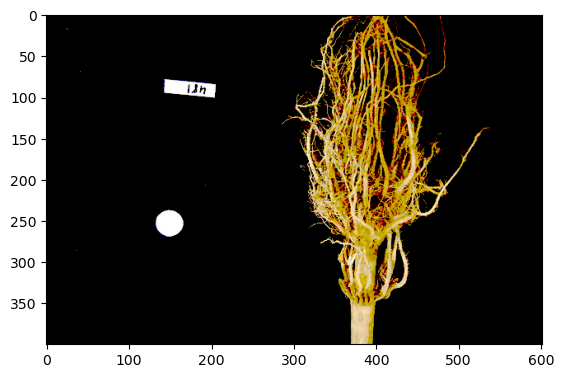

In [17]:
maize_roots = iio.imread(uri="data/maize-root-cluster.jpg")
maize_roots = np.array(maize_roots)

# keep only high-intensity pixels
maize_roots[maize_roots < 128] = 0

fig, ax = plt.subplots()
ax.imshow(maize_roots)
plt.show()

### Converting colour images to grayscale

It is often easier to work with grayscale images, which have a single channel, instead of colour images, which have three channels. scikit-image offers the function `ski.color.rgb2gray()` to achieve this. This function adds up the three colour channels in a way that matches human colour perception, see the [scikit-image documentation](https://scikit-image.org/docs/dev/api/skimage.color.html#skimage.color.rgb2gray) for details. It returns a grayscale image with floating point values in the range from 0 to 1. We can use the function ski.util.img_as_ubyte() in order to convert it back to the original data type and the data range back 0 to 255. Note, however, that it is often better to use image values represented by floating point values, because using floating point numbers is numerically more stable.

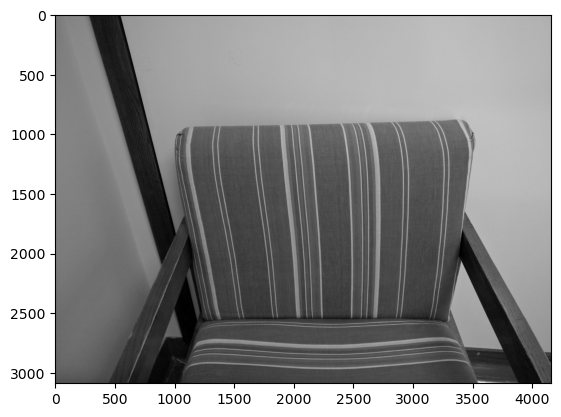

In [18]:
chair = iio.imread(uri="data/chair.jpg")

# convert to grayscale and display
gray_chair = ski.color.rgb2gray(chair)

fig, ax = plt.subplots()
ax.imshow(gray_chair, cmap="gray")
plt.show()

We can also load colour images as grayscale directly by passing the argument `mode="L"` to `iio.imread()`.

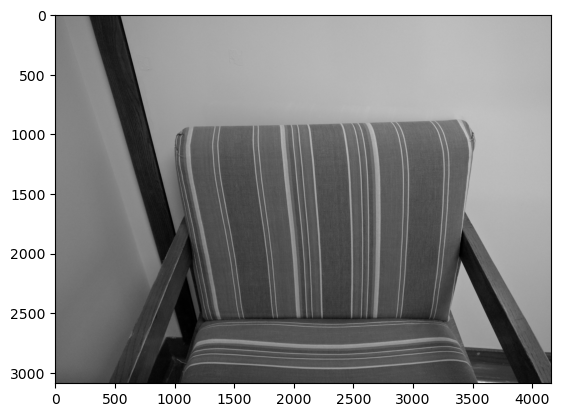

In [19]:
gray_chair = iio.imread(uri="data/chair.jpg", mode="L")

fig, ax = plt.subplots()
ax.imshow(gray_chair, cmap="gray")
plt.show()

#### Challenge: Keeping only low intensity pixels

A little earlier, we showed how we could use Python and scikit-image to turn on only the high intensity pixels from an image, while turning all the low intensity pixels off. Now, you can practice doing the opposite - keeping all the low intensity pixels while changing the high intensity ones.

The file `data/sudoku.png` is an RGB image of a sudoku puzzle:

![Sudoku](https://datacarpentry.github.io/image-processing/data/sudoku.png)

Your task is to load the image in grayscale format and turn all of the bright pixels in the image to a light gray colour. In other words, mask the bright pixels that have a pixel value greater than 192 and set their value to 192 (the value 192 is chosen here because it corresponds to 75% of the range 0-255 of an 8-bit pixel). The results should look like this:

![Sudoku gray](https://datacarpentry.github.io/image-processing/fig/sudoku-gray.png)

In [20]:
### TODO ###

### Access via slicing

As noted in the previous lesson scikit-image images are stored as NumPy arrays, so we can use array slicing to select rectangular areas of an image. Then, we can save the selection as a new image, change the pixels in the image, and so on. It is important to remember that coordinates are specified in (ry, cx) order and that colour values are specified in (r, g, b) order when doing these manipulations.

Consider this image of a whiteboard, and suppose that we want to create a sub-image with just the portion that says “odd + even = odd,” along with the red box that is drawn around the words. We can determine the coordinates of the corners of the area we wish to extract by hovering the mouse near the points of interest and noting the coordinates (remember to run %matplotlib widget first if you haven’t already). If we do that, we might settle on a rectangular area with an upper-left coordinate of (135, 60) and a lower-right coordinate of (480, 150), as shown in this version of the whiteboard picture:

![Whiteboard image](https://datacarpentry.github.io/image-processing/fig/board-coordinates.jpg)

Note that the coordinates in the preceding image are specified in (cx, ry) order. Now if our entire whiteboard image is stored as a NumPy array named image, we can create a new image of the selected region like this:

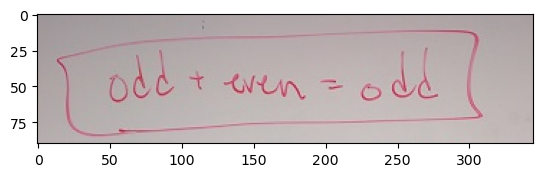

In [21]:
board = iio.imread(uri="data/board.jpg")

region = np.s_[60:150, 135:480]

clipped_board = board[*region, :]

fig, ax = plt.subplots()
ax.imshow(clipped_board)
plt.show()

We can also "wipe" this area on the board. First, we sample a single pixel’s colour at a particular location of the image, saving it in a variable named color, which creates a 1 × 1 × 3 NumPy array with the blue, green, and red colour values for the pixel located at (ry = 330, cx = 90). Then, with the img[60:151, 135:481] = color command, we modify the image in the specified area. From a NumPy perspective, this changes all the pixel values within that range to array saved in the color variable. In this case, the command “erases” that area of the whiteboard, replacing the words with a beige colour, as shown in the final image produced by the program:

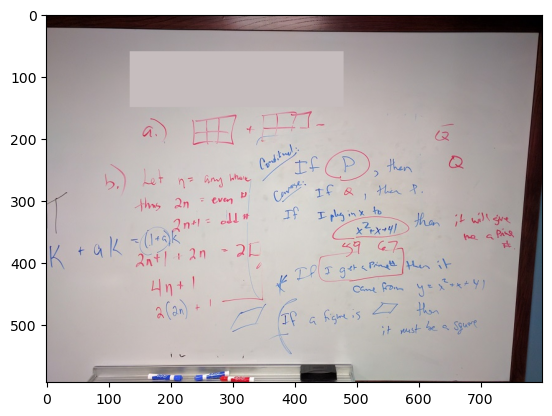

In [22]:
color = board[330, 90]

board[*region] = color

fig, ax = plt.subplots()
ax.imshow(board)
plt.show()

#### Now you

Using the image `data/maize-root-cluster.jpg` to practice the techniques you just learned.

1. Create a sub-image containing only the plant and its roots from `data/maize-root-cluster.jpg`.
2. Dipsplay the subimage.
3. Save the subimage to a new file.

## Drawing and Bitwise Operations

You may review the full episode [Drawing and Bitwise Operations](https://datacarpentry.github.io/image-processing/04-drawing.html) online.

### Masking images

Often we wish to select only a portion of an image to analyze, and ignore the rest. Creating a rectangular sub-image with slicing, as we did in the [Working with scikit-image episode](https://datacarpentry.github.io/image-processing/03-skimage-images.html) is one option for simple cases. 

Another option is to create another special image, of the same size as the original, with white pixels indicating the region to save and black pixels everywhere else. Such an image is called a mask. Consider this image of maize seedlings:

![Maize seedlings](https://datacarpentry.github.io/image-processing/fig/maize-seedlings.jpg)

Suppose we want to analyze only the area of the image containing the roots themselves. Hovering over the image with our mouse, could tell us that the upper-left coordinate of the sub-area we are interested in is (44, 357), while the lower-right coordinate is (720, 740). These coordinates are shown in (x, y) order.

NumPy allows indexing of images/arrays with “boolean” arrays of the same size. Indexing with a boolean array is also called mask indexing. The “pixels” in such a mask array can only take two values: True or False. When indexing an image with such a mask, only pixel values at positions where the mask is True are accessed. In preparing a mask, we sometimes need to be able to draw a shape - e.g., a circle or a rectangle - on a black image. scikit-image provides tools to do that.

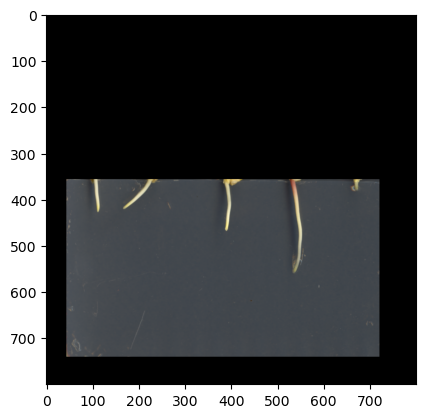

In [23]:
# Load and display the original image
maize_seedlings = iio.imread(uri="data/maize-seedlings.tif")
masked_maize_seedlings = maize_seedlings.copy()

# create the mask image
mask = np.ones(shape=maize_seedlings.shape[0:2], dtype="bool")

# draw a filled rectangle on the mask image
rr, cc = ski.draw.rectangle(start=(357, 44), end=(740, 720))
mask[rr, cc] = False

# apply the mask
masked_maize_seedlings[mask] = 0

# Display mask image
fig, ax = plt.subplots()
ax.imshow(masked_maize_seedlings)
plt.show()

#### Challenge: Other drawing operations

There are other functions for drawing on images, in addition to the `ski.draw.rectangle()` function. We can draw circles, lines, text, and other shapes as well. These drawing functions may be useful later on, to help annotate images that our programs produce. Practice some of these functions here.

Circles can be drawn with the `ski.draw.disk()` function, which takes two parameters: the (ry, cx) point of the centre of the circle, and the radius of the circle. There is an optional shape parameter that can be supplied to this function. It will limit the output coordinates for cases where the circle dimensions exceed the ones of the image.

Lines can be drawn with the `ski.draw.line()` function, which takes four parameters: the (ry, cx) coordinate of one end of the line, and the (ry, cx) coordinate of the other end of the line.

Other drawing functions supported by scikit-image can be found in the [scikit-image reference pages](https://scikit-image.org/docs/dev/api/skimage.draw.html?highlight=draw#module-skimage.draw).

1. Create an empty, black image with a size of 800x600 pixels. Recall that a colour image has three channels for the colours red, green, and blue (RGB, cf. Image Basics). Hence we need to create a 3D array of shape (600, 800, 3) where the last dimension represents the RGB colour channels.
2. Draw some other coloured shapes and lines on the image, perhaps something like this:

![Shapes on black b ackground](https://datacarpentry.github.io/image-processing/fig/drawing-practice.jpg)

In [24]:
### TODO ###

#### Challenge: Masking a 96-well plate image

Consider the image `data/wellplate-01.jpg` of a 96-well plate that has been scanned on a flatbed scanner.

![Wellplate](https://datacarpentry.github.io/image-processing/data/wellplate-01.jpg)

Suppose that we are interested in the colours of the solutions in each of the wells. We do not care about the colour of the rest of the image, i.e., the plastic that makes up the well plate itself. Your task is to write some code that will produce a mask that will mask out everything except for the wells. To help with this, you should use the text file `data/centers.txt` that contains the (cx, ry) coordinates of the centre of each of the 96 wells in this image. You may assume that each of the wells has a radius of 16 pixels.

Your program should produce output that looks like this:

![Masked wellplate](https://datacarpentry.github.io/image-processing/fig/wellplate-01-masked.jpg)

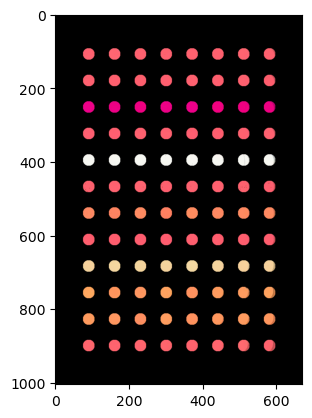

In [25]:
### TODO ###

wellplate = iio.imread("data/wellplate-01.jpg")
centers = np.loadtxt("data/centers.txt")

fig, ax = plt.subplots()
#ax.imshow(wellplate)
#plt.show()

mask = np.zeros(shape=wellplate.shape[:2], dtype='bool')

for cx, ry in centers:
    rr, cc = ski.draw.disk(center=(ry,cx), radius=16, shape=wellplate.shape[:2])
    mask[rr, cc] = True

wellplate_masked = wellplate.copy()
wellplate_masked[~mask] = 0

ax.imshow(wellplate_masked)
plt.show()   

#### Challenge: Masking a 96-well plate -- reloaded

If you spent some time looking at the contents of the data/centers.txt file from the previous challenge, you may have noticed that the centres of each well in the image are very regular. Assuming that the images are scanned in such a way that the wells are always in the same place, and that the image is perfectly oriented (i.e., it does not slant one way or another), we could produce our well plate mask without having to read in the coordinates of the centres of each well. Assume that the centre of the upper left well in the image is at location cx = 91 and ry = 108, and that there are 70 pixels between each centre in the cx dimension and 72 pixels between each centre in the ry dimension. Each well still has a radius of 16 pixels. Write a Python program that produces the same output image as in the previous challenge, but without having to read in the centers.txt file. Hint: use nested for loops.

In [26]:
### TODO ###

## Blurring Images

You may review the full episode [Blurring Images](https://datacarpentry.github.io/image-processing/06-blurring.html) online.

### Blurring Images

When processing an image, we are often interested in identifying objects represented within it so that we can perform some further analysis of these objects, e.g., by counting them, measuring their sizes, etc. An important concept associated with the identification of objects in an image is that of edges: the lines that represent a transition from one group of similar pixels in the image to another different group. One example of an edge is the pixels that represent the boundaries of an object in an image, where the background of the image ends and the object begins.

When we blur an image, we make the colour transition from one side of an edge in the image to another smooth rather than sudden. The effect is to average out rapid changes in pixel intensity. Blurring is a very common operation we need to perform before other tasks such as thresholding. There are several different blurring functions in the ski.filters module, so we will focus on just one here, the Gaussian blur.

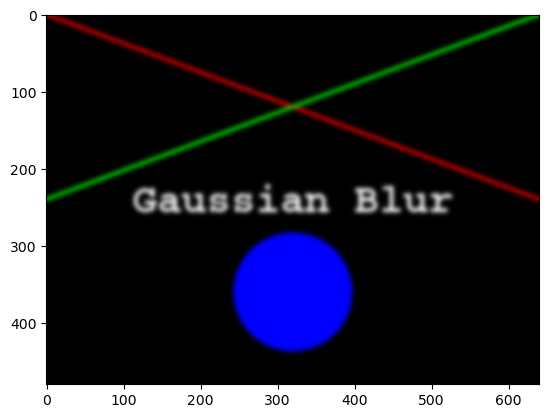

In [27]:
image = iio.imread(uri="data/gaussian-original.png")

sigma = 3.0

# apply Gaussian blur, creating a new image
blurred = ski.filters.gaussian(image, sigma=(sigma, sigma), truncate=3.5, channel_axis=-1)

fig, ax = plt.subplots()
ax.imshow(blurred)
plt.show()

#### Now you

The size and shape of the kernel used to blur an image can have a significant effect on the result of the blurring and any downstream analysis carried out on the blurred image. The next two exercises ask you to experiment with the sigma values of the kernel, which is a good way to develop your understanding of how the choice of kernel can influence the result of blurring.

1. Blur the image with a range of smaller and larger sigma values. What effect does the sigma value have on the blurred image?
2. Try running the code above with different sigmas in the ry and cx direction. What is the effect of applying an asymmetric kernel to blurring an image?

The Gaussian blur is a way to apply a low-pass filter in scikit-image. It is often used to remove Gaussian (i.e., random) noise in an image. For other kinds of noise, e.g., “salt and pepper”, a median filter is typically used. See the skimage.filters documentation for a list of available filters.

3. Experiment with other filters from `skimage.filters`.

## Creating Histograms

You may review the full episode [Creating Histograms](https://datacarpentry.github.io/image-processing/05-creating-histograms.html) online.

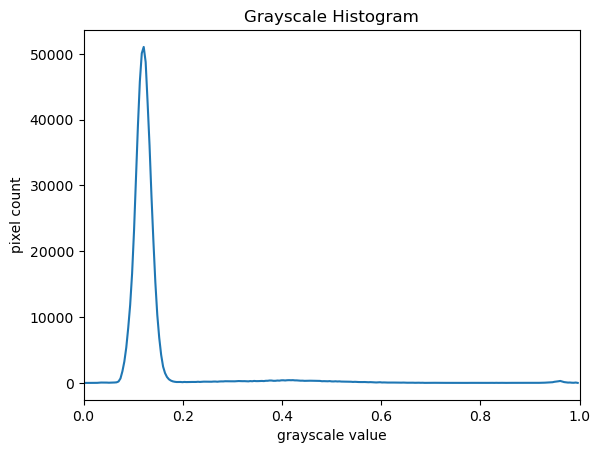

In [28]:
# read the image of a plant seedling as grayscale from the outset
plant_seedling = iio.imread(uri="data/plant-seedling.jpg", mode="L")

# convert the image to float dtype with a value range from 0 to 1
plant_seedling = ski.util.img_as_float(plant_seedling)

# create the histogram
histogram, bin_edges = np.histogram(plant_seedling, bins=256, range=(0, 1))

# plot the histogram
fig, ax = plt.subplots()
ax.plot(bin_edges[0:-1], histogram)
ax.set_title("Grayscale Histogram")
ax.set_xlabel("grayscale value")
ax.set_ylabel("pixel count")
ax.set_xlim([0.0, 1.0])
plt.show()

### Colour Histograms

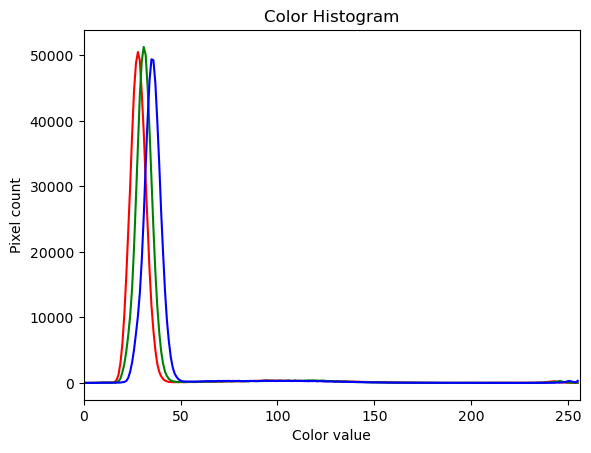

In [29]:
plant_seedling = iio.imread(uri="data/plant-seedling.jpg")

# tuple to select colors of each channel line
colors = ("red", "green", "blue")

# create the histogram plot, with three lines, one for each color
fig, ax = plt.subplots()

for channel_id, color in enumerate(colors):
    histogram, bin_edges = np.histogram(
        plant_seedling[:, :, channel_id], bins=256, range=(0, 256)
    )
    ax.plot(bin_edges[0:-1], histogram, color=color)

ax.set_title("Color Histogram")
ax.set_xlabel("Color value")
ax.set_ylabel("Pixel count")
ax.set_xlim([0, 256])
plt.show()

#### Challenge: Using a mask for a histogram 

Looking at the first histogram above, you will notice that there is a large number of very dark pixels, as indicated in the chart by the spike around the grayscale value 0.12. That is not so surprising, since the original image is mostly black background. What if we want to focus more closely on the leaf of the seedling? That is where a mask enters the picture!

1. Using techniques from the [Drawing and Bitwise Operations episode](https://datacarpentry.github.io/image-processing/04-drawing.html), create a mask for the the leaf of the seedling.
2. Apply the mask to the input image before passing it to the `np.histogram` function.
3. Compute the histogram of the masked image.
4. Plot the histogram.

Your histogram of the masked area should look something like this:

![Masked histogram](https://datacarpentry.github.io/image-processing/fig/plant-seedling-grayscale-histogram-mask.png)

#### Challenge: Colour histogram with a mask

We can also apply a mask to the images we apply the colour histogram process to, in the same way we did for grayscale histograms.

Consider the image `data/wellplate-02.tif` of a well plate, where various chemical sensors have been applied to water and various concentrations of hydrochloric acid and sodium hydroxide. Suppose we are interested in the colour histogram of one of the sensors in the well plate image, specifically, the seventh well from the left in the topmost row, which shows Erythrosin B reacting with water.

1. Create a circular mask to select only the desired well.
2. Then, use that mask to apply the colour histogram operation to that well.

The code should produce a colour histogram that looks like this:

![Masked colour histogram](https://datacarpentry.github.io/image-processing/fig/wellplate-02-histogram.png)

## Thresholding

You may review the full episode [Thresholding](https://datacarpentry.github.io/image-processing/07-thresholding.html) online.

### Simple thresholding

First, we will load the original image, convert it to grayscale, and de-noise it as in the [Blurring Images episode](https://datacarpentry.github.io/image-processing/06-blurring.html).

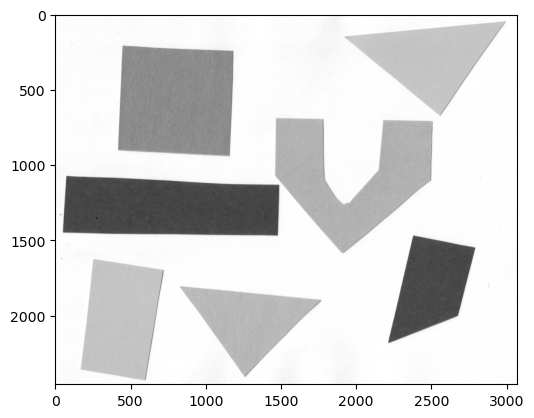

In [30]:
shapes01 = iio.imread(uri="data/shapes-01.jpg")

# convert the image to grayscale
gray_shapes = ski.color.rgb2gray(shapes01)

# blur the image to denoise
blurred_shapes = ski.filters.gaussian(gray_shapes, sigma=1.0)

fig, ax = plt.subplots()
ax.imshow(blurred_shapes, cmap="gray")
plt.show()

Now suppose we want to select only the shapes from the image. In other words, we want to leave the pixels belonging to the shapes “on,” while turning the rest of the pixels “off,” by setting their colour channel values to zeros. The scikit-image library has several different methods of thresholding. We will start with the simplest version, which involves an important step of human input. Specifically, in this simple, fixed-level thresholding, we have to provide a threshold value t.

So we would like to apply the threshold t such that pixels with grayscale values on one side of t will be turned “on”, while pixels with grayscale values on the other side will be turned “off”. How might we do that? Remember that grayscale images contain pixel values in the range from 0 to 1, so we are looking for a threshold t in the closed range [0.0, 1.0]. We see in the image that the geometric shapes are “darker” than the white background but there is also some light gray noise on the background. One way to determine a “good” value for t is to look at the grayscale histogram of the image and try to identify what grayscale ranges correspond to the shapes in the image or the background.

The histogram for the shapes image shown above can be produced as in the [Creating Histograms episode](https://datacarpentry.github.io/image-processing/05-creating-histograms.html).

(0.0, 1.0)

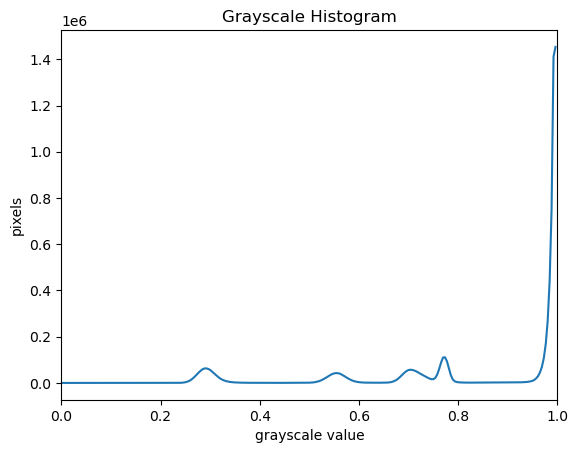

In [31]:
# create a histogram of the blurred grayscale image
histogram, bin_edges = np.histogram(blurred_shapes, bins=256, range=(0.0, 1.0))

fig, ax = plt.subplots()
ax.plot(bin_edges[0:-1], histogram)
ax.set_title("Grayscale Histogram")
ax.set_xlabel("grayscale value")
ax.set_ylabel("pixels")
ax.set_xlim(0, 1.0)

Since the image has a white background, most of the pixels in the image are white. This corresponds nicely to what we see in the histogram: there is a peak near the value of 1.0. If we want to select the shapes and not the background, we want to turn off the white background pixels, while leaving the pixels for the shapes turned on. So, we should choose a value of t somewhere before the large peak and turn pixels above that value “off”. Let us choose t=0.8.

To apply the threshold t, we can use the NumPy comparison operators to create a mask. Here, we want to turn “on” all pixels which have values smaller than the threshold, so we use the less operator < to compare the blurred_image to the threshold t. The operator returns a mask, that we capture in the variable binary_mask. It has only one channel, and each of its values is either 0 or 1. The binary mask created by the thresholding operation can be shown with ax.imshow, where the False entries are shown as black pixels (0-valued) and the True entries are shown as white pixels (1-valued).

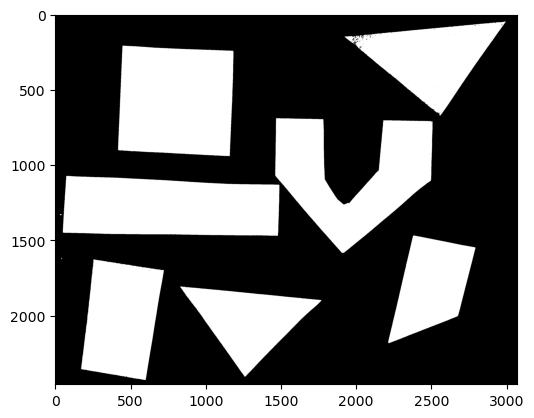

In [32]:
# create a mask based on the threshold
t = 0.8
binary_mask = blurred_shapes < t

fig, ax = plt.subplots()
ax.imshow(binary_mask, cmap="gray")
plt.show()

We can now apply the binary_mask to the original coloured image as we have learned in the [Drawing and Bitwise Operations episode](https://datacarpentry.github.io/image-processing/04-drawing.html). What we are left with is only the coloured shapes from the original.

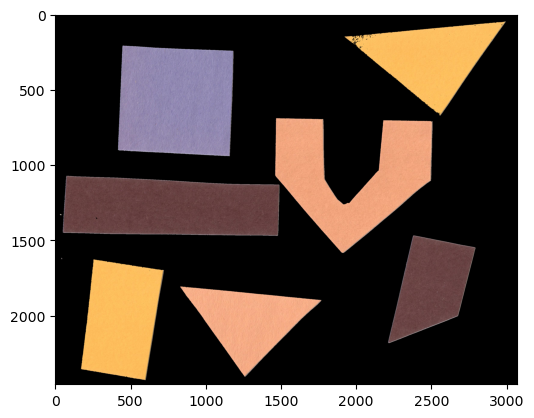

In [33]:
# use the binary_mask to select the "interesting" part of the image
selection = shapes01.copy()
selection[~binary_mask] = 0

fig, ax = plt.subplots()
ax.imshow(selection)
plt.show()

#### Now you

Now, it is your turn to practice. Suppose we want to use simple thresholding to select only the coloured shapes (in this particular case we consider grayish to be a colour, too) from the image `data/shapes-02.jpg`:

![Shapes](https://datacarpentry.github.io/image-processing/data/shapes-02.jpg)

1. Plot the grayscale histogram and examine the distribution of grayscale values in the image. What do you think would be a good value for the threshold t?
2. Create a mask to turn the pixels above the threshold on and pixels below the threshold off. Note that unlike the image with a white background we used above, here the peak for the background colour is at a lower gray level than the shapes. Therefore, change the comparison operator less < to greater > to create the appropriate mask.
3. Apply the mask to the image and view the thresholded image. If everything works as it should, your output should show only the coloured shapes on a black background.

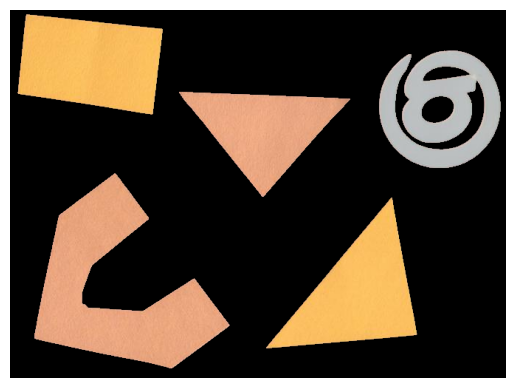

In [48]:
shapes2_rgb = iio.imread("data/shapes-02.jpg")

shapes2 = ski.color.rgb2gray(shapes2_rgb)
shapes2 = ski.filters.gaussian(shapes2, sigma=1.0)

histogram, bin_edges = np.histogram(shapes2, bins=256, range=(0.0, 1.0))

t = ski.filters.threshold_otsu(shapes2)

mask = shapes2 > t

shapes2_rgb[~mask] = 0

fig, ax = plt.subplots()
ax.imshow(shapes2_rgb)
ax.set_axis_off()
plt.show()

### Automatic thresholding

The downside of the simple thresholding technique is that we have to make an educated guess about the threshold t by inspecting the histogram. There are also automatic thresholding methods that can determine the threshold automatically for us. One such method is [Otsu’s method](https://en.wikipedia.org/wiki/Otsu%27s_method). It is particularly useful for situations where the grayscale histogram of an image has two peaks that correspond to background and objects of interest.

In [ ]:
maize_roots = iio.imread(uri="data/maize-root-cluster.jpg")

# convert the image to grayscale
gray_image = ski.color.rgb2gray(maize_roots)

# blur the image to denoise
blurred_image = ski.filters.gaussian(gray_image, sigma=1.0)

# show the histogram of the blurred image
histogram, bin_edges = np.histogram(blurred_image, bins=256, range=(0.0, 1.0))
fig, ax = plt.subplots()
ax.plot(bin_edges[0:-1], histogram)
ax.set_title("Graylevel histogram")
ax.set_xlabel("gray value")
ax.set_ylabel("pixel count")
ax.set_xlim(0, 1.0)
plt.show()

The histogram has a significant peak around 0.2 and then a broader “hill” around 0.6 followed by a smaller peak near 1.0. Looking at the grayscale image, we can identify the peak at 0.2 with the background and the broader peak with the foreground. Thus, this image is a good candidate for thresholding with Otsu’s method. The mathematical details of how this works are complicated (see the [scikit-image documentation](https://scikit-image.org/docs/dev/api/skimage.filters.html#threshold-otsu) if you are interested), but the outcome is that Otsu’s method finds a threshold value between the two peaks of a grayscale histogram which might correspond well to the foreground and background depending on the data and application.

The `ski.filters.threshold_otsu()` function can be used to determine the threshold automatically via Otsu’s method. Then NumPy comparison operators can be used to apply it as before. Here are the Python commands to determine the threshold t with Otsu’s method.

In [ ]:
# perform automatic thresholding
t = ski.filters.threshold_otsu(blurred_image)
print("Found automatic threshold t = {}.".format(t))

For this root image and a Gaussian blur with the chosen sigma of 1.0, the computed threshold value is 0.42. No we can create a binary mask with the comparison operator >. As we have seen before, pixels above the threshold value will be turned on, those below the threshold will be turned off. Finally, we use the mask to select the foreground:

In [ ]:
# create a binary mask with the threshold found by Otsu's method
binary_mask = blurred_image > t

# apply the binary mask to select the foreground
selection = maize_roots.copy()
selection[~binary_mask] = 0

fig, ax = plt.subplots()
ax.imshow(selection)
plt.show()

### Application: measuring root mass

Suppose we are interested in the amount of plant material in each image, and in particular how that amount changes from image to image. Perhaps the images represent the growth of the plant over time, or perhaps the images show four different maize varieties at the same phase of their growth. The question we would like to answer is, “how much root mass is in each image?”

We will first construct a Python program to measure this value for a single image. Our strategy will be this:

1. Read the image, converting it to grayscale as it is read. For this application we do not need the colour image.
2. Blur the image.
3. Use Otsu’s method of thresholding to create a binary image, where the pixels that were part of the maize plant are white, and everything else is black.
4. Save the binary image so it can be examined later.
5. Count the white pixels in the binary image, and divide by the number of pixels in the image. This ratio will be a measure of the root mass of the plant in the image.
6. Output the name of the image processed and the root mass ratio.

Here is a Python function that implements this root-mass-measuring strategy. Since the function is intended to produce numeric output without human interaction, it does not display any of the images. Almost all of the commands should be familiar, and in fact, it may seem simpler than the code we have worked on thus far, because we are not displaying any of the images.

In [58]:
def measure_root_mass(filename, sigma=1.0):

    # read the original image, converting to grayscale on the fly
    image = iio.imread(uri=filename, mode="L")

    # blur before thresholding
    blurred_image = ski.filters.gaussian(image, sigma=sigma)

    # perform automatic thresholding to produce a binary image
    t = ski.filters.threshold_otsu(blurred_image)
    binary_mask = blurred_image > t

    # determine root mass ratio
    root_pixels = np.count_nonzero(binary_mask)
    density = root_pixels / binary_mask.size

    return density

import glob
all_files = glob.glob("data/trial-*.jpg")
for filename in all_files:
    density = measure_root_mass(filename=filename, sigma=1.5)
    # output in format suitable for .csv
    print(filename, density, sep=",")

data/trial-016.jpg,0.04907247340425532
data/trial-216.jpg,0.14205152925531914
data/trial-020.jpg,0.06381366356382978
data/trial-293.jpg,0.13665791223404256


#### Challenge: Measuring more accurately

You may have noticed in the section on automatic thresholding that the thresholded image does include regions of the image aside of the plant root: the numbered labels and the white circles in each image are preserved during the thresholding, because their grayscale values are above the threshold. Therefore, our calculated root mass ratios include the white pixels of the label and white circle that are not part of the plant root. Those extra pixels affect how accurate the root mass calculation is!

1. How might we remove the labels and circles before calculating the ratio, so that our results are more accurate? Think about some options given what we have learned so far.
2. Implement an enhanced version of the function measure_root_mass that applies simple binary thresholding to remove the white circle and label from the image before applying Otsu’s method.

In [ ]:
def enhanced_root_mass(filename, sigma):
    ### TODO ###
    return density

#### Challenge: Thresholding a bacteria colony image

In the images directory data/, you will find an image named `colonies-01.tif`. This is one of the images you will be working with in the morphometric challenge at the end of the workshop.

![Bacteria colonies](https://datacarpentry.github.io/image-processing/fig/colonies-01.jpg)

1. Plot and inspect the grayscale histogram of the image to determine a good threshold value for the image.
2. Create a binary mask that leaves the pixels in the bacteria colonies “on” while turning the rest of the pixels in the image “off”.

## Connected Component Analysis

You may review the full episode [Connected Component Analysis](https://datacarpentry.github.io/image-processing/08-connected-components.html) online.

#### Now you: Pixel Neighborhoods

Consider the following image array:
```
0 0 0 0 0 0 0 0
0 1 0 0 0 1 1 0
0 0 1 0 0 0 0 0
0 1 0 1 1 1 0 0
0 1 0 1 1 0 0 0
0 0 0 0 0 0 0 0
```

1. How many connected components with 1 orthogonal jump?
2. How many connected components with 2 orthogonal jumps?

### Connected Component Analysis

In order to find the objects in an image, we want to employ an operation that is called Connected Component Analysis (CCA). This operation takes a binary image as an input. Usually, the False value in this image is associated with background pixels, and the True value indicates foreground, or object pixels. Such an image can be produced, e.g., with thresholding. Given a thresholded image, the connected component analysis produces a new labeled image with integer pixel values. Pixels with the same value, belong to the same object. scikit-image provides connected component analysis in the function `ski.measure.label()`. Let us add this function to the already familiar steps of thresholding an image.

In [ ]:
def connected_components(filename, sigma=1.0, t=0.5, connectivity=2):
    # load the image
    image = iio.imread(filename)
    # convert the image to grayscale
    gray_image = ski.color.rgb2gray(image)
    # denoise the image with a Gaussian filter
    blurred_image = ski.filters.gaussian(gray_image, sigma=sigma)
    # mask the image according to threshold
    binary_mask = blurred_image < t
    # perform connected component analysis
    labeled_image, count = ski.measure.label(binary_mask, connectivity=connectivity, return_num=True)
    return labeled_image, count

labeled_image, count = connected_components(filename="data/shapes-01.jpg", sigma=2.0, t=0.9, connectivity=2)

# convert the label image to color image
colored_label_image = ski.color.label2rgb(labeled_image, bg_label=0)

fig, ax = plt.subplots()
ax.imshow(colored_label_image)
ax.set_axis_off();
plt.show()

#### Now you
1. Using the function `connected_components`, find two ways of printing out the number of objects found in the image.
2. What number of objects would you expect to get?
3. How does changing the sigma and threshold values influence the result?

### Morphometrics

Morphometrics is concerned with the quantitative analysis of objects and considers properties such as size and shape. For the example of the images with the shapes, our intuition tells us that the objects should be of a certain size or area. So we could use a minimum area as a criterion for when an object should be detected. To apply such a criterion, we need a way to calculate the area of objects found by connected components. Recall how we determined the root mass in the [Thresholding episode](https://datacarpentry.github.io/image-processing/07-thresholding.html) by counting the pixels in the binary mask. But here we want to calculate the area of several objects in the labeled image. The scikit-image library provides the function `ski.measure.regionprops` to measure the properties of labeled regions. It returns a list of `RegionProperties` that describe each connected region in the images. The properties can be accessed using the attributes of the `RegionProperties` data type. Here we will use the properties `area` and `label`. You can explore the [scikit-image documentation](https://scikit-image.org/docs/stable/api/skimage.measure.html) to learn about other properties available.

In [ ]:
# compute object features and extract object areas
object_features = ski.measure.regionprops(labeled_image)
object_areas = [int(objf["area"]) for objf in object_features]
object_areas

#### Now you

Similar to how we determined a “good” threshold in the [Thresholding episode](https://datacarpentry.github.io/image-processing/07-thresholding.html), it is often helpful to inspect the [histogram](https://datacarpentry.github.io/image-processing/05-creating-histograms.html) of an object property. For example, we want to look at the distribution of the object areas.

1. Create and examine a histogram of the object areas obtained with `ski.measure.regionprops`.
2. What does the histogram tell you about the objects?
3. Find a way to calculate the number of objects by only counting objects above a certain area.
4. Enhance the connected_components function such that it automatically removes objects that are below a certain area that is passed to the function as an optional parameter.
5. Finally, display the image with the objects coloured according to the magnitude of their area. In practice, this can be used with other properties to give visual cues of the object properties.

In [ ]:
### TODO ###

## Capstone Challenge

You may review the full episode [Capstone Challenge](https://datacarpentry.github.io/image-processing/09-challenges.html) online.

As mentioned in the workshop introduction, your morphometric challenge is to determine how many bacteria colonies are in each of these images:

![Bacteria colony 1](https://datacarpentry.github.io/image-processing/fig/colonies-01.jpg)
![Bacteria colony 2](https://datacarpentry.github.io/image-processing/fig/colonies-02.jpg)
![Bacteria colony 3](https://datacarpentry.github.io/image-processing/fig/colonies-03.jpg)

The image files can be found at `data/colonies-01.tif`, `data/colonies-02.tif`, and `data/colonies-03.tif`.

1. Write the code that counts the number of bacteria colonies in each image.
2. For each image, produce a new image that highlights the colonies.
3. Print out the number of colonies for each image.
4. Modify your function colony counting to
    1. exclude objects smaller than a specified size, and
    2. use an automated thresholding approach, e.g. Otsu, to mask the colonies.

The images should look similar to this one:

![Highlighted bacteria colonies](https://datacarpentry.github.io/image-processing/fig/colonies-01-summary.png)

In [ ]:
### TODO ###